In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
df = pd.read_csv('/kaggle/input/datasets/rohankamble2009/house-dataset/dataset (1).csv')

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [48]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [49]:
# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# fill numerical with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# fill categorical with mode
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(df.isnull().sum().sum())

0


In [50]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

top_corr = corr['SalePrice'].sort_values(ascending=False)

print(top_corr.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


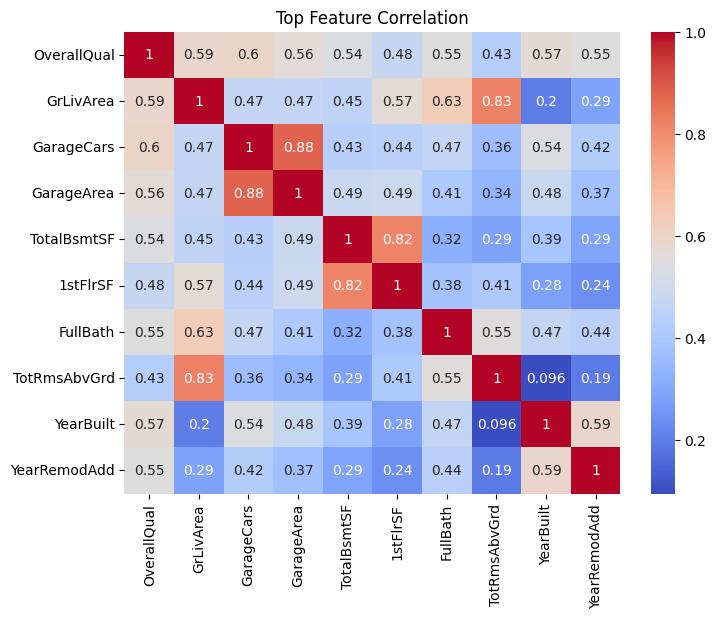

In [51]:
top_features = top_corr.index[1:11]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlation")
plt.show()

In [52]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [53]:
X = pd.get_dummies(X, drop_first=True)

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [56]:
import pandas as pd

importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(10))

OverallQual    0.557486
GrLivArea      0.122240
2ndFlrSF       0.035236
TotalBsmtSF    0.033762
BsmtFinSF1     0.029266
1stFlrSF       0.026585
LotArea        0.016827
GarageArea     0.016318
GarageCars     0.012290
YearBuilt      0.012007
dtype: float64


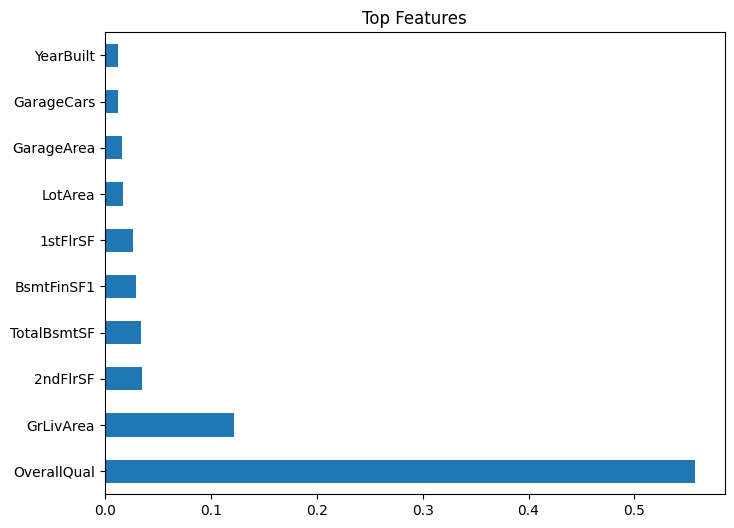

In [57]:
plt.figure(figsize=(8,6))
feat_imp.head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

In [58]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']

In [59]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 20230.08541573438
R2 Score: 0.6556028072511307


In [60]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Results
MAE: 17641.30417808219
R2 Score: 0.8928649876911031
